In [29]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [30]:
def load_and_preprocess_data():
    """Fetches the MNIST dataset and prepares raw labels for looping."""
    print("Fetching MNIST dataset...")
    mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')
    
    # Normalize features
    X = mnist.data.values.astype('float32') / 255.0
    y = mnist.target.values.astype('int')
    
    # Split dataset (keeping raw 0-9 labels for now)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=60000, test_size=10000, random_state=42
    )
    print(f"Data Loaded: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples.\n")
    return X_train, X_test, y_train, y_test

In [31]:
def train_voted_perceptron_binary(X_train, y_train, target_digit, d, epochs):
    """Trains a Kernel Voted Perceptron for a single binary task."""
    print(f"--- Training: Digit {target_digit} vs Rest | d={d}, Epochs={epochs} ---")
    start_train_time = time.time()
    
    X_train = np.ascontiguousarray(X_train, dtype=np.float32)
    
    # Preallocate mistakes array to avoid repeated memory allocation
    max_mistakes = 20000 # Increased slightly just in case lower degrees make more mistakes
    M_x_arr = np.empty((max_mistakes, 784), dtype=np.float32)
    M_y_arr = np.empty(max_mistakes, dtype=np.float32)
    mistake_count = 0
    C = [0]
    
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_train[i]
            
            if mistake_count == 0:
                v_dot_x = 0.0
            else:
                if d == 1:
                    v_dot_x = np.dot(M_y_arr[:mistake_count], (np.dot(M_x_arr[:mistake_count], x_i) + 1.0))
                else:
                    v_dot_x = np.dot(M_y_arr[:mistake_count], (np.dot(M_x_arr[:mistake_count], x_i) + 1.0) ** d)
                
            y_hat = 1 if v_dot_x >= 0 else -1
            
            if y_hat == y_i:
                C[-1] += 1
            else:
                # Expand arrays if we hit the limit
                if mistake_count >= max_mistakes:
                    max_mistakes *= 2
                    M_x_arr = np.resize(M_x_arr, (max_mistakes, 784))
                    M_y_arr = np.resize(M_y_arr, max_mistakes)

                M_x_arr[mistake_count] = x_i
                M_y_arr[mistake_count] = y_i
                mistake_count += 1
                C.append(1)
                
    # Save the history matrices, discarding unused pre-allocated memory
    final_M_x = M_x_arr[:mistake_count].copy()
    final_M_y = M_y_arr[:mistake_count].copy()
    final_C = np.array(C)

    print(f"  > Training completed in {time.time() - start_train_time:.1f}s | Total mistakes: {mistake_count}")
    return final_M_x, final_M_y, final_C

In [32]:
def evaluate_binary(X_test, y_test, M_x, M_y, C_vec, d=5, batch_size=1000):
    """Evaluates the binary model and calculates multiple confidence metrics."""
    start_eval_time = time.time()
    
    y_pred_all = np.zeros(len(X_test))
    
    # Confidence arrays
    conf_streak = np.zeros(len(X_test))
    conf_abs_diff = np.zeros(len(X_test))
    conf_weighted = np.zeros(len(X_test))
    
    for i in range(0, len(X_test), batch_size):
        X_batch = X_test[i:i+batch_size]
        
        if len(M_x) > 0:
            if d == 1:
                K_matrix = (np.dot(X_batch, M_x.T) + 1.0)
            else:
                K_matrix = (np.dot(X_batch, M_x.T) + 1.0) ** d
                
            K_weighted = K_matrix * M_y
            
            # Tracking incremental votes
            H_vals = np.hstack([np.zeros((len(X_batch), 1)), np.cumsum(K_weighted, axis=1)])
            signs = np.where(H_vals >= 0, 1, -1)
            
            batch_scores = np.dot(signs, C_vec)
            
        # Standard Prediction based on weighted votes
        y_pred_batch = np.where(batch_scores >= 0, 1, -1)
        y_pred_all[i:i+batch_size] = y_pred_batch
        
        # --- METHOD 1: Unbroken Streak ---
        rev_signs = signs[:, ::-1]
        rev_C = C_vec[::-1]
        
        matches = (rev_signs == rev_signs[:, 0:1]).astype(int)
        valid_streak_mask = np.cumprod(matches, axis=1)
        conf_streak[i:i+batch_size] = np.dot(valid_streak_mask, rev_C)

        # --- METHOD 2: Survival-Weighted Confidence |Sum(vote * C)| ---
        conf_weighted[i:i+batch_size] = np.abs(batch_scores)

    print(f"  > Evaluation Complete in {time.time() - start_eval_time:.1f}s")
    
    mistakes_mask = (y_pred_all != y_test)
    return conf_streak, conf_abs_diff, conf_weighted, mistakes_mask

In [33]:
def get_error_rates(confidences, mistakes):
    """Helper function to calculate error rates and coverages across confidence thresholds."""
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    coverages = []
    total_samples = len(confidences)
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        coverage_pct = (retained / total_samples) * 100
        
        # Enforce minimum 20 samples to prevent random variance artifacts
        if retained > 20: 
            error_rate = np.mean(mistakes[keep_mask]) * 100
            error_rates.append(error_rate)
        else:
            error_rates.append(np.nan)
            
        coverages.append(coverage_pct)
            
    return thresholds, error_rates, coverages

In [34]:
def plot_calibration(conf_streak, conf_weighted, mistakes, target_digit, d):
    """Generates a 2x2 comparison of the confidence methods with explanatory annotations."""
    t_streak, err_streak, cov_streak = get_error_rates(conf_streak, mistakes)
    t_weight, err_weight, cov_weight = get_error_rates(conf_weighted, mistakes)

    # Changed grid to 2x2 and adjusted the width from 22 to 16
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    bbox_props = dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="orange", lw=1.5, alpha=0.9)

    # ROW 1: Error Rate vs Threshold (Clean lines without dot markers)
    axes[0, 0].plot(t_streak, err_streak, 'r-', linewidth=2.5)
    axes[0, 0].set_xlabel('Threshold (Minimum Consecutive Matching Votes)')
    axes[0, 0].set_ylabel('Error Rate (%)', fontsize=12)
    axes[0, 0].set_title('1. Unbroken Streak\n(How long did the final models agree?)', pad=15, fontsize=14)
    axes[0, 0].text(0.95, 0.95, "Ideal: Error drops as\nThreshold increases →", 
                    transform=axes[0, 0].transAxes, ha='right', va='top', bbox=bbox_props)
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)

    # Shifted from axes[0, 2] to axes[0, 1] and updated title numbering
    axes[0, 1].plot(t_weight, err_weight, 'g-', linewidth=2.5)
    axes[0, 1].set_xlabel('Threshold (|Weighted Pos - Weighted Neg|)')
    axes[0, 1].set_title('2. Survival-Weighted Confidence\n(Margin of victory scaled by model quality)', pad=15, fontsize=14)
    axes[0, 1].text(0.95, 0.95, "Ideal: Error drops as\nThreshold increases →", 
                    transform=axes[0, 1].transAxes, ha='right', va='top', bbox=bbox_props)
    axes[0, 1].grid(True, linestyle='--', alpha=0.7)

    # ROW 2: Error Rate vs Coverage (Clean lines without dot markers)
    axes[1, 0].plot(cov_streak, err_streak, 'r-', linewidth=2.5)
    axes[1, 0].set_xlabel('Coverage (% of dataset predicted)')
    axes[1, 0].set_ylabel('Error Rate (%)', fontsize=12)
    axes[1, 0].set_title('Unbroken Streak vs. Coverage', pad=15, fontsize=14)
    axes[1, 0].invert_xaxis() 
    axes[1, 0].text(0.05, 0.95, "← Ideal: Error stays low until\nforced to predict on hard cases (100%)", 
                    transform=axes[1, 0].transAxes, ha='left', va='top', bbox=bbox_props)
    axes[1, 0].grid(True, linestyle='--', alpha=0.7)

    # Shifted from axes[1, 2] to axes[1, 1]
    axes[1, 1].plot(cov_weight, err_weight, 'g-', linewidth=2.5)
    axes[1, 1].set_xlabel('Coverage (% of dataset predicted)')
    axes[1, 1].set_title('Survival-Weighted Confidence vs. Coverage', pad=15, fontsize=14)
    axes[1, 1].invert_xaxis()
    axes[1, 1].text(0.05, 0.95, "← Ideal: Error stays low until\nforced to predict on hard cases (100%)", 
                    transform=axes[1, 1].transAxes, ha='left', va='top', bbox=bbox_props)
    axes[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.suptitle(f"Evaluating Confidence: Binary Kernel Voted Perceptron (Digit {target_digit} vs Rest | d={d})\n"
                 f"How well do different internal metrics separate correct predictions from mistakes?", 
                 fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
    plt.show()

Fetching MNIST dataset...
Data Loaded: 60000 train samples, 10000 test samples.


 STARTING EXPERIMENT FOR DIGIT: 0
--- Training: Digit 0 vs Rest | d=1, Epochs=1 ---
  > Training completed in 13.4s | Total mistakes: 1041
  > Evaluation Complete in 0.2s


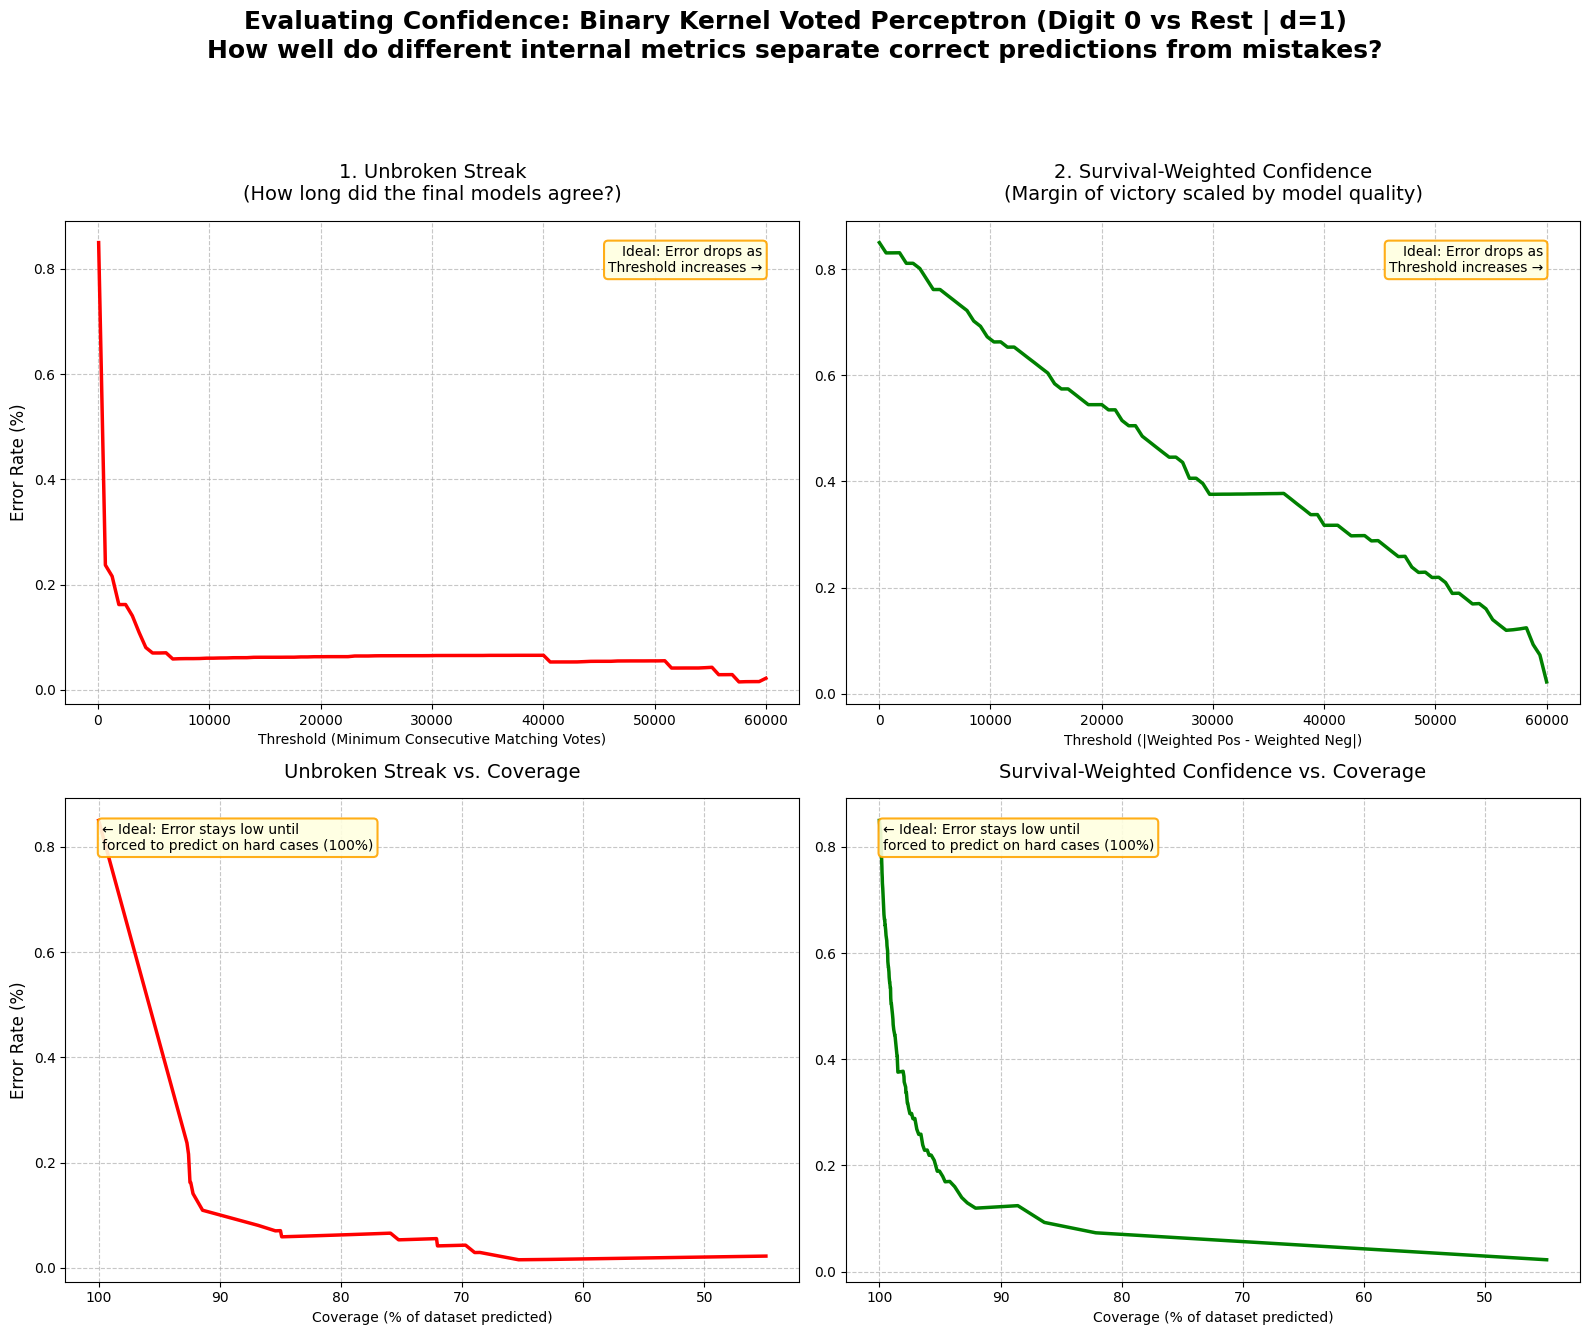

--- Training: Digit 0 vs Rest | d=2, Epochs=1 ---
  > Training completed in 9.9s | Total mistakes: 553
  > Evaluation Complete in 0.1s


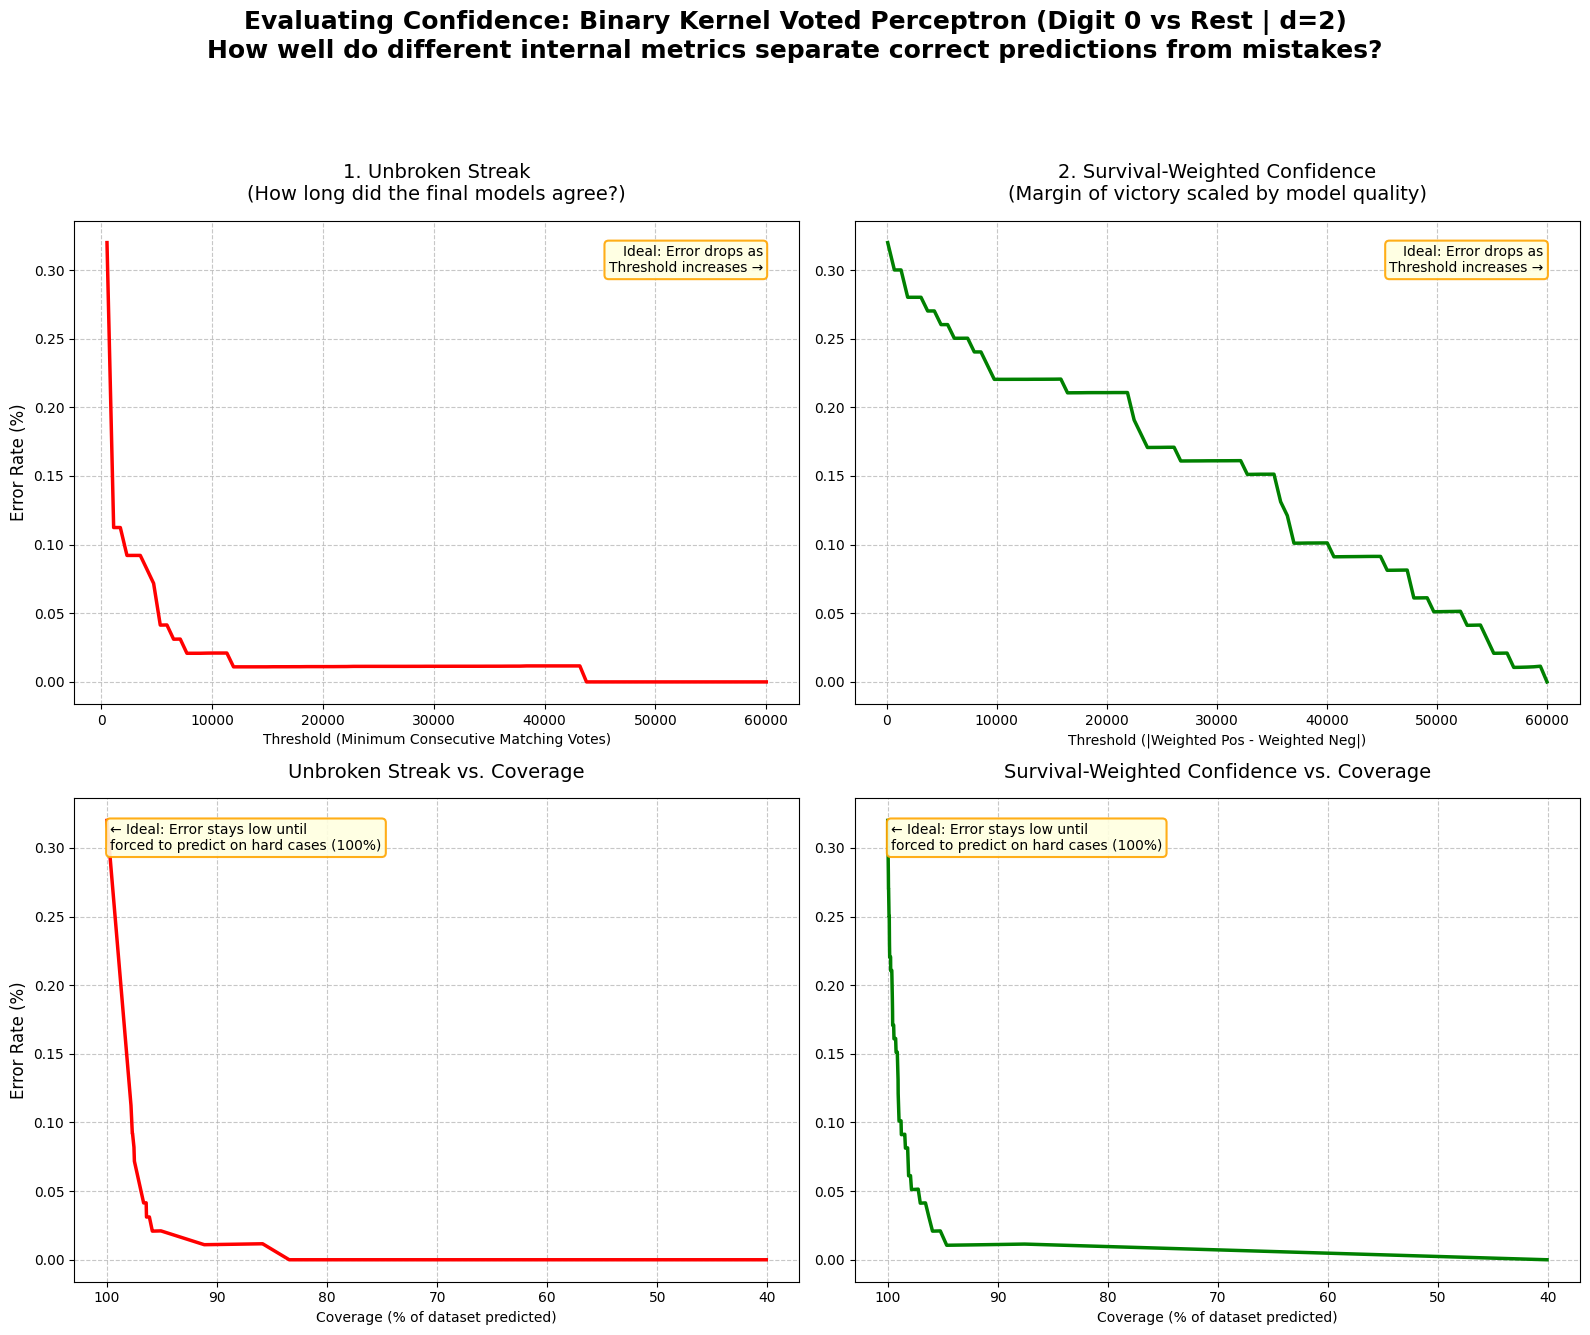

--- Training: Digit 0 vs Rest | d=3, Epochs=1 ---
  > Training completed in 10.0s | Total mistakes: 477
  > Evaluation Complete in 0.1s


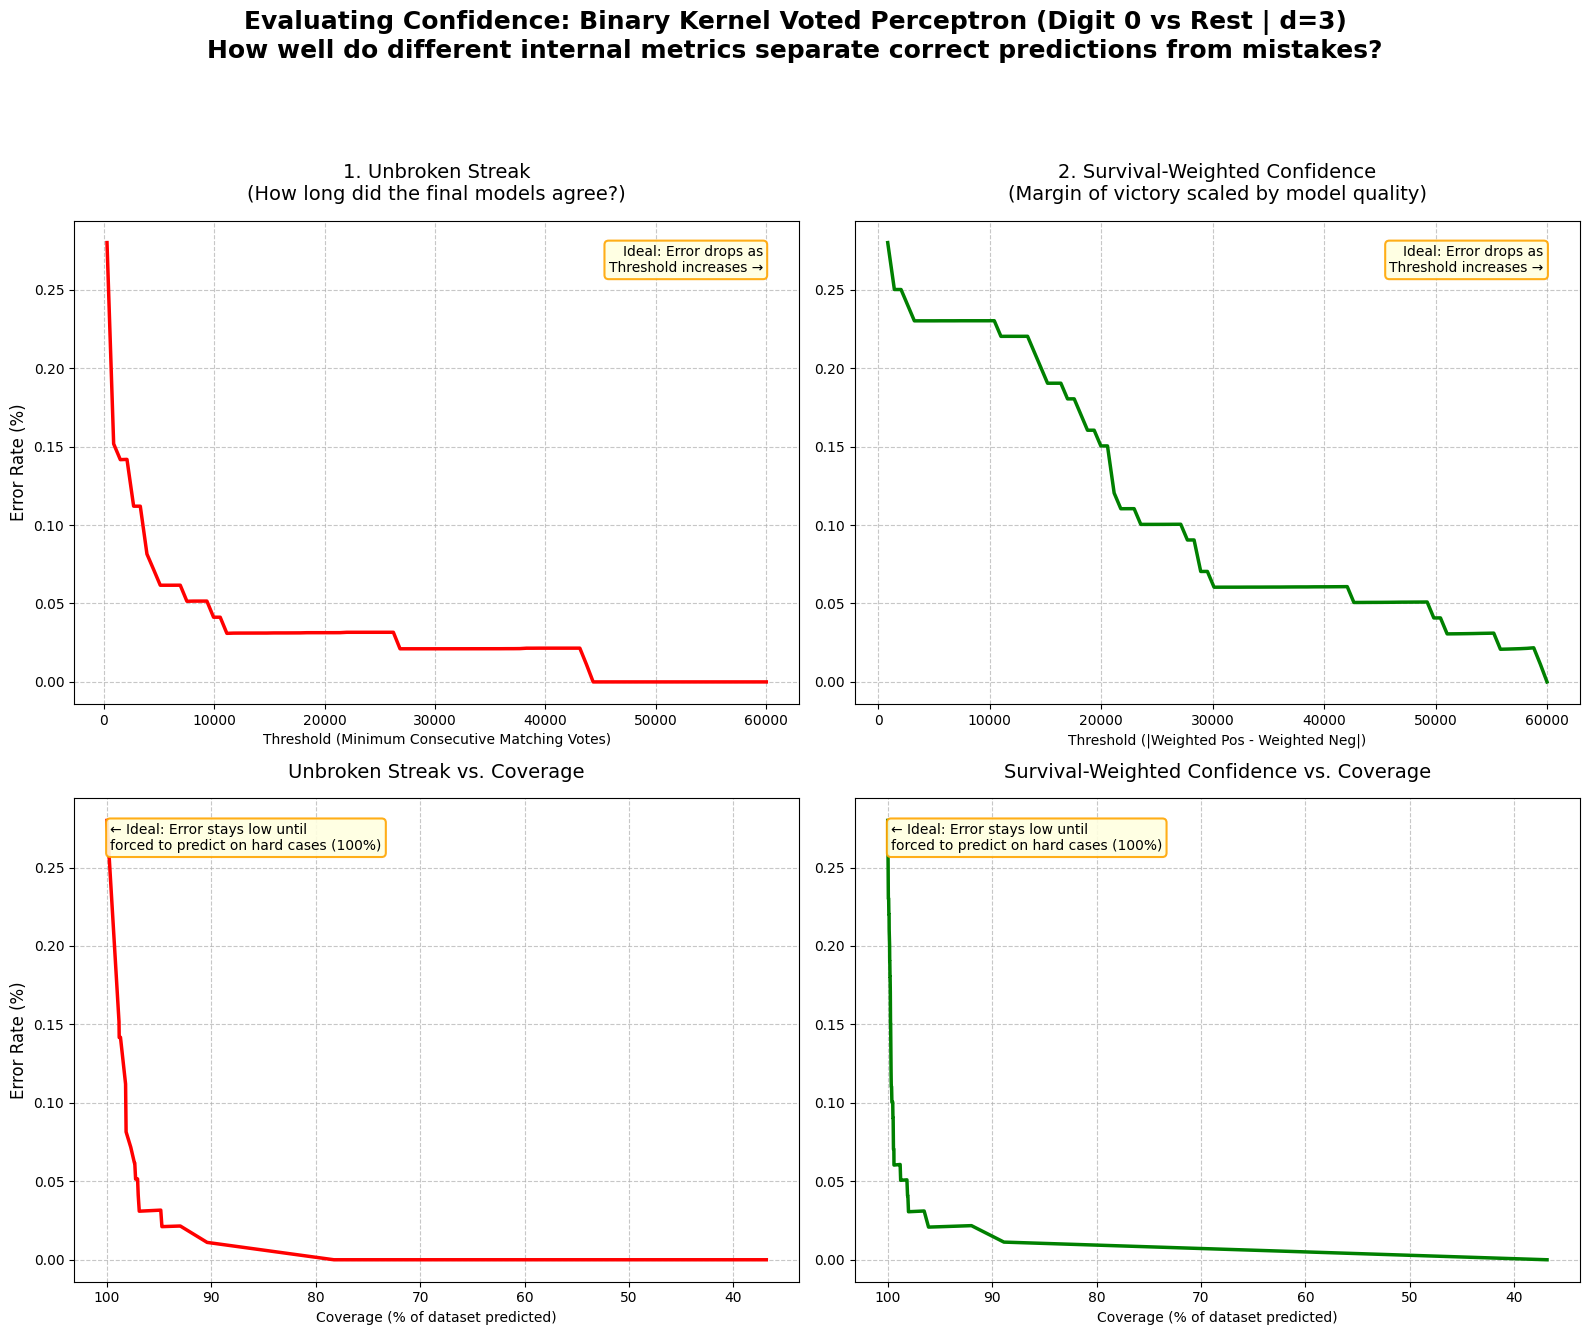

--- Training: Digit 0 vs Rest | d=4, Epochs=1 ---
  > Training completed in 10.0s | Total mistakes: 475
  > Evaluation Complete in 0.1s


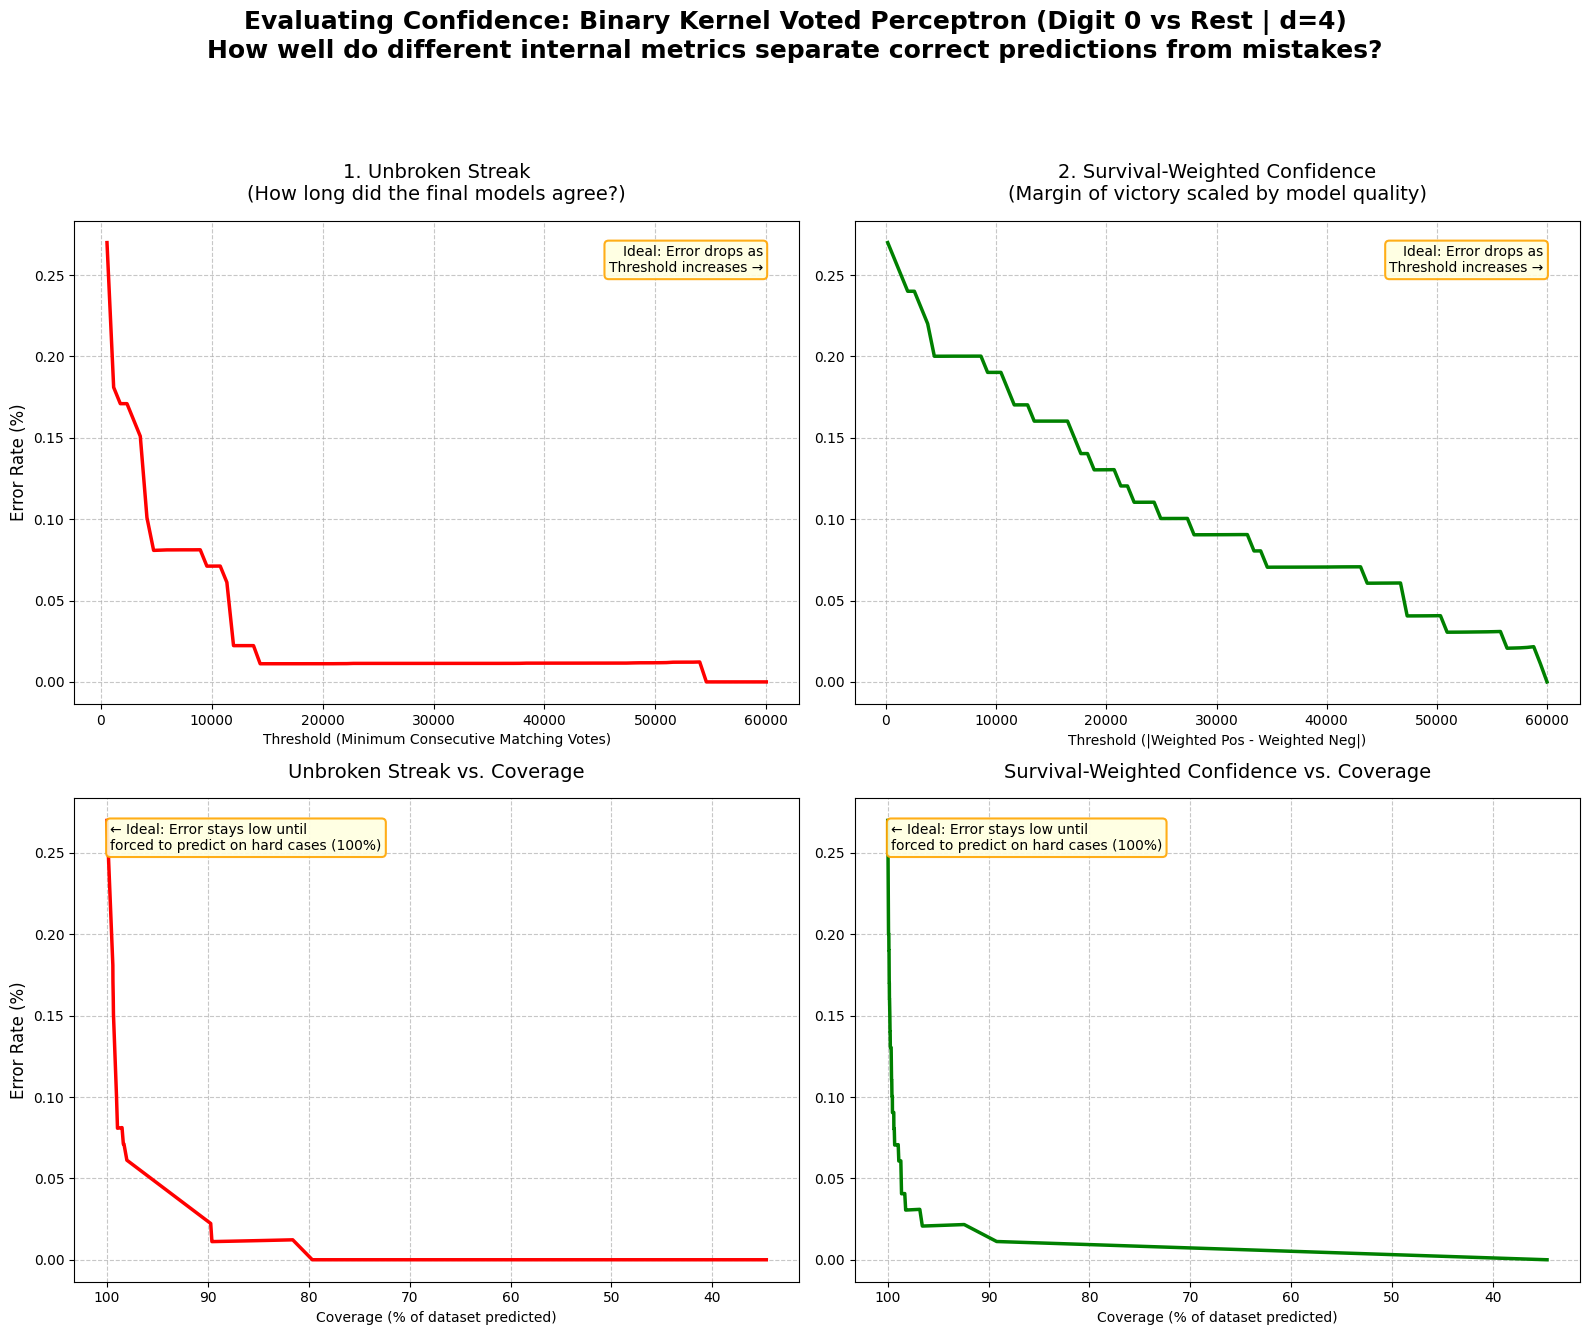


 STARTING EXPERIMENT FOR DIGIT: 1
--- Training: Digit 1 vs Rest | d=1, Epochs=1 ---
  > Training completed in 11.2s | Total mistakes: 964
  > Evaluation Complete in 0.2s


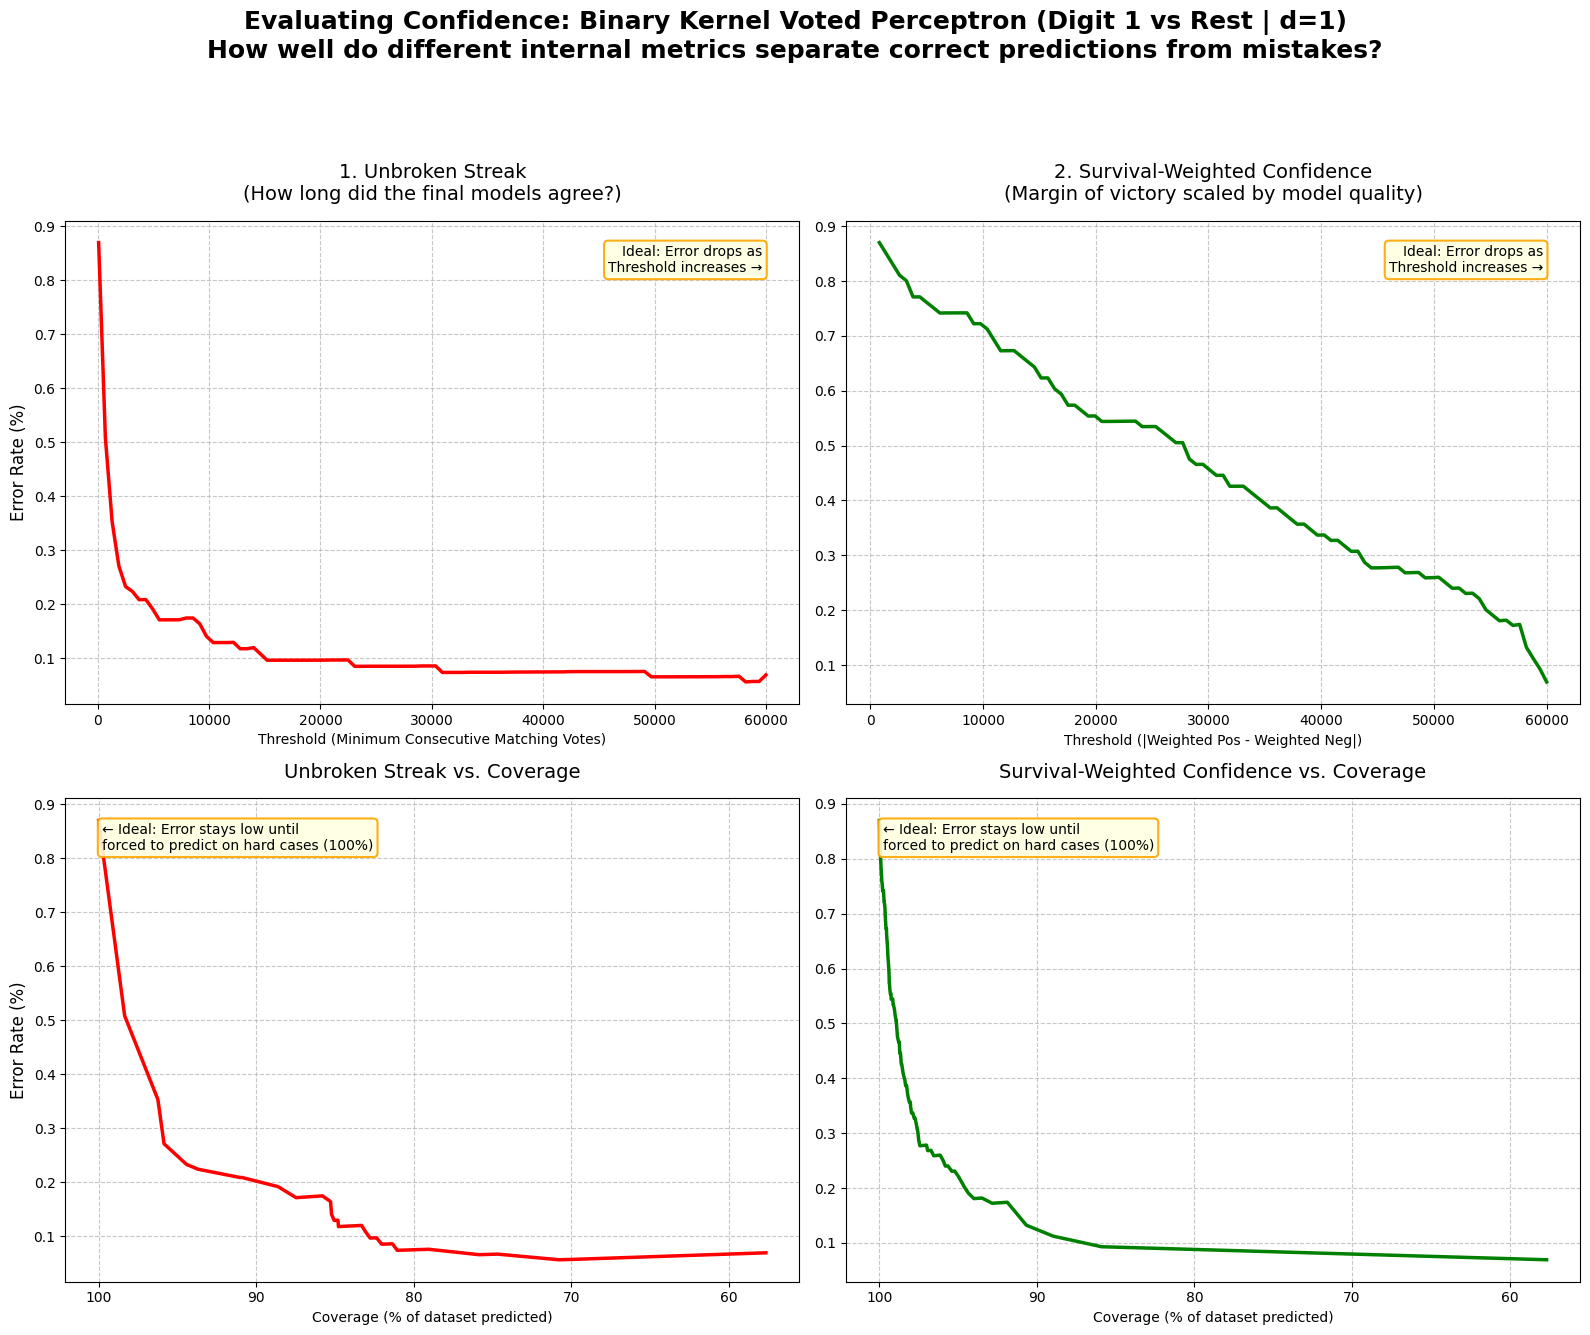

--- Training: Digit 1 vs Rest | d=2, Epochs=1 ---
  > Training completed in 9.1s | Total mistakes: 435
  > Evaluation Complete in 0.1s


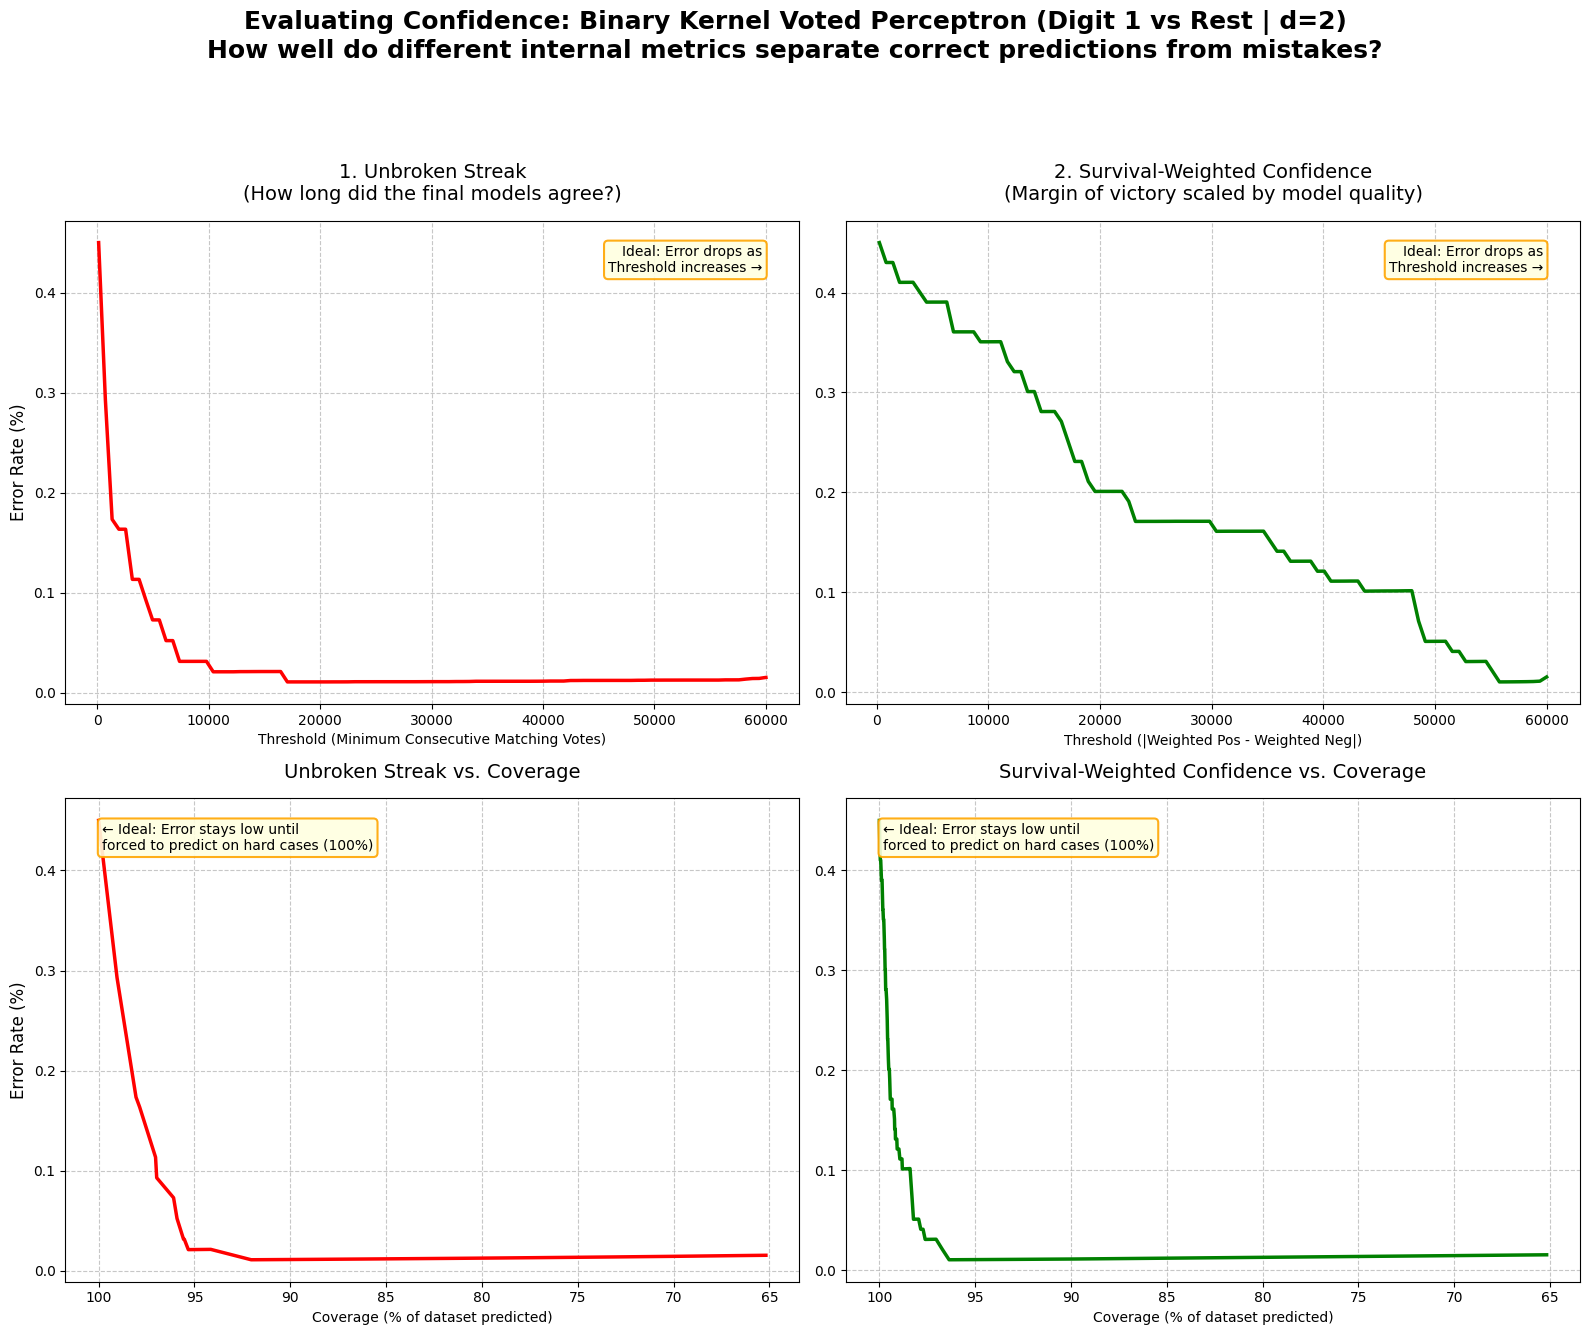

--- Training: Digit 1 vs Rest | d=3, Epochs=1 ---
  > Training completed in 9.1s | Total mistakes: 391
  > Evaluation Complete in 0.1s


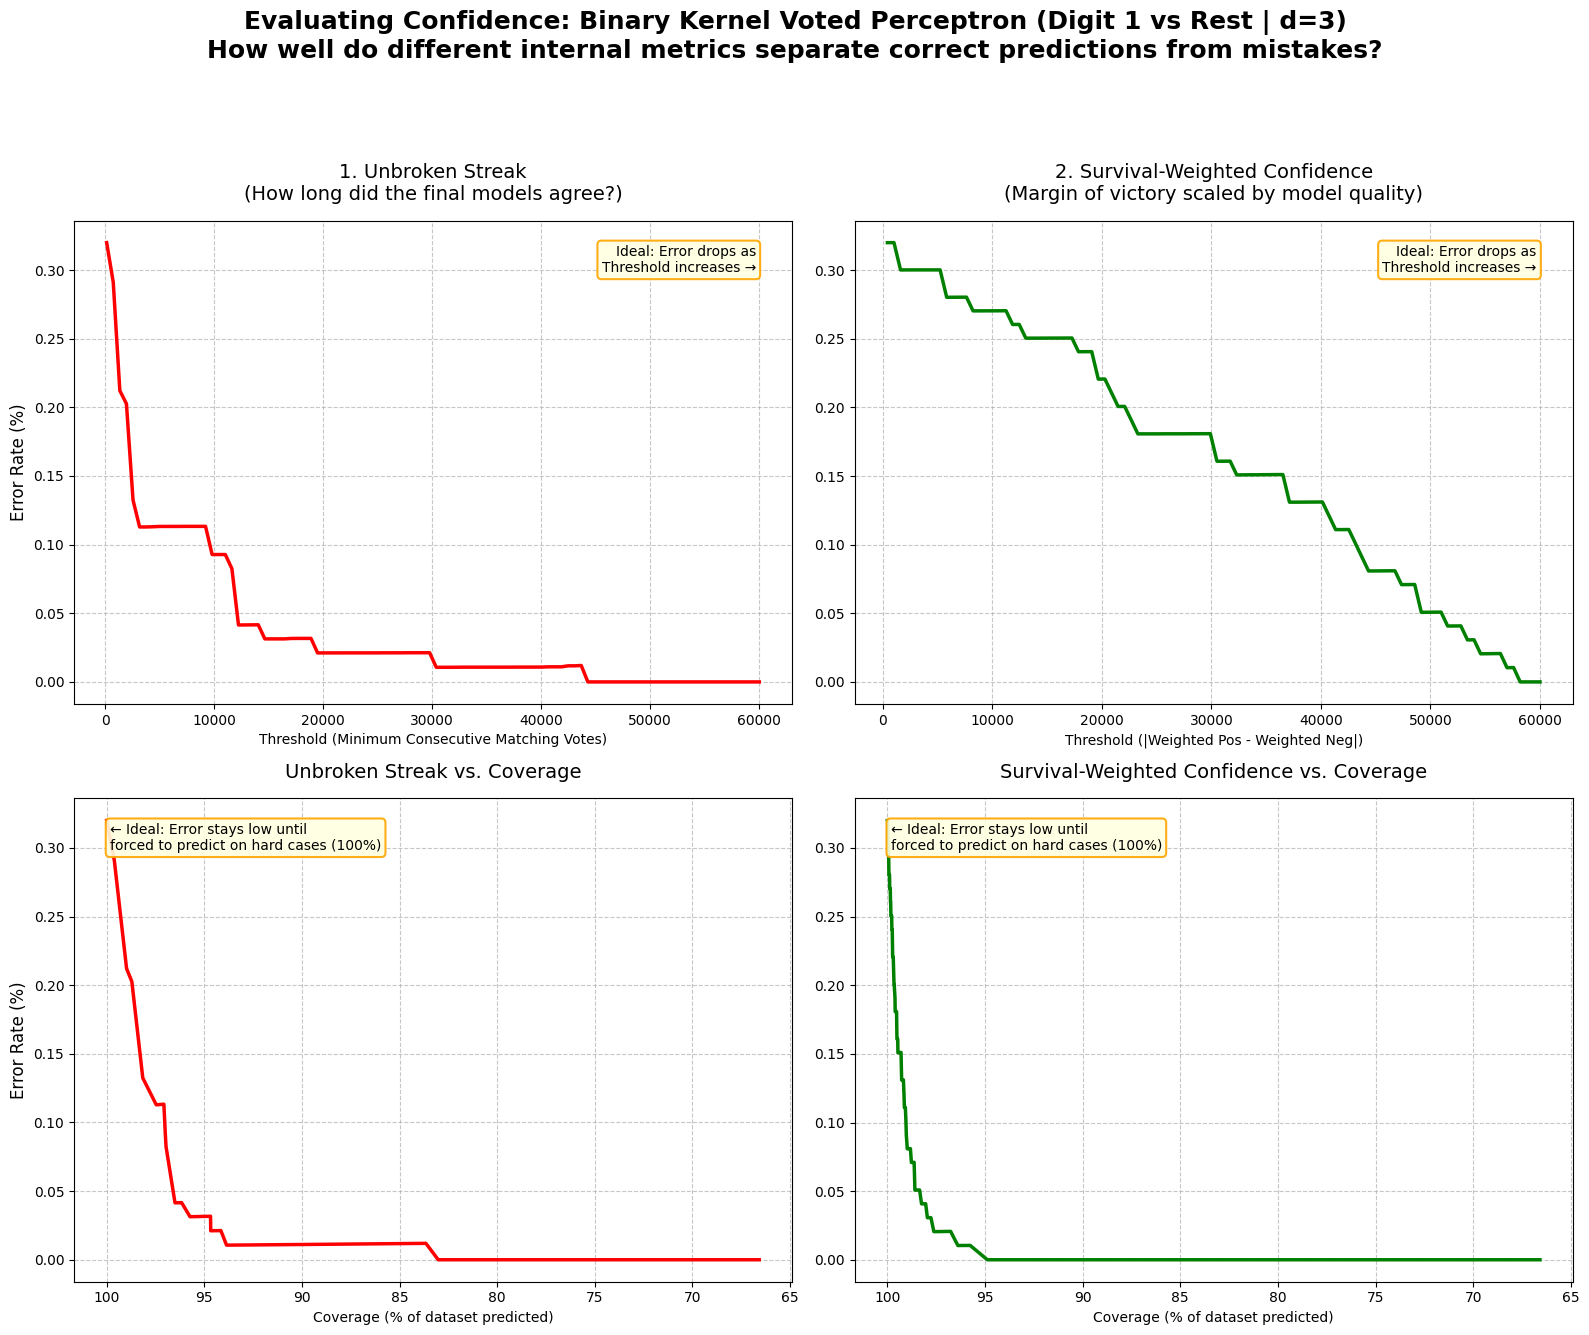

--- Training: Digit 1 vs Rest | d=4, Epochs=1 ---
  > Training completed in 9.1s | Total mistakes: 390
  > Evaluation Complete in 0.1s


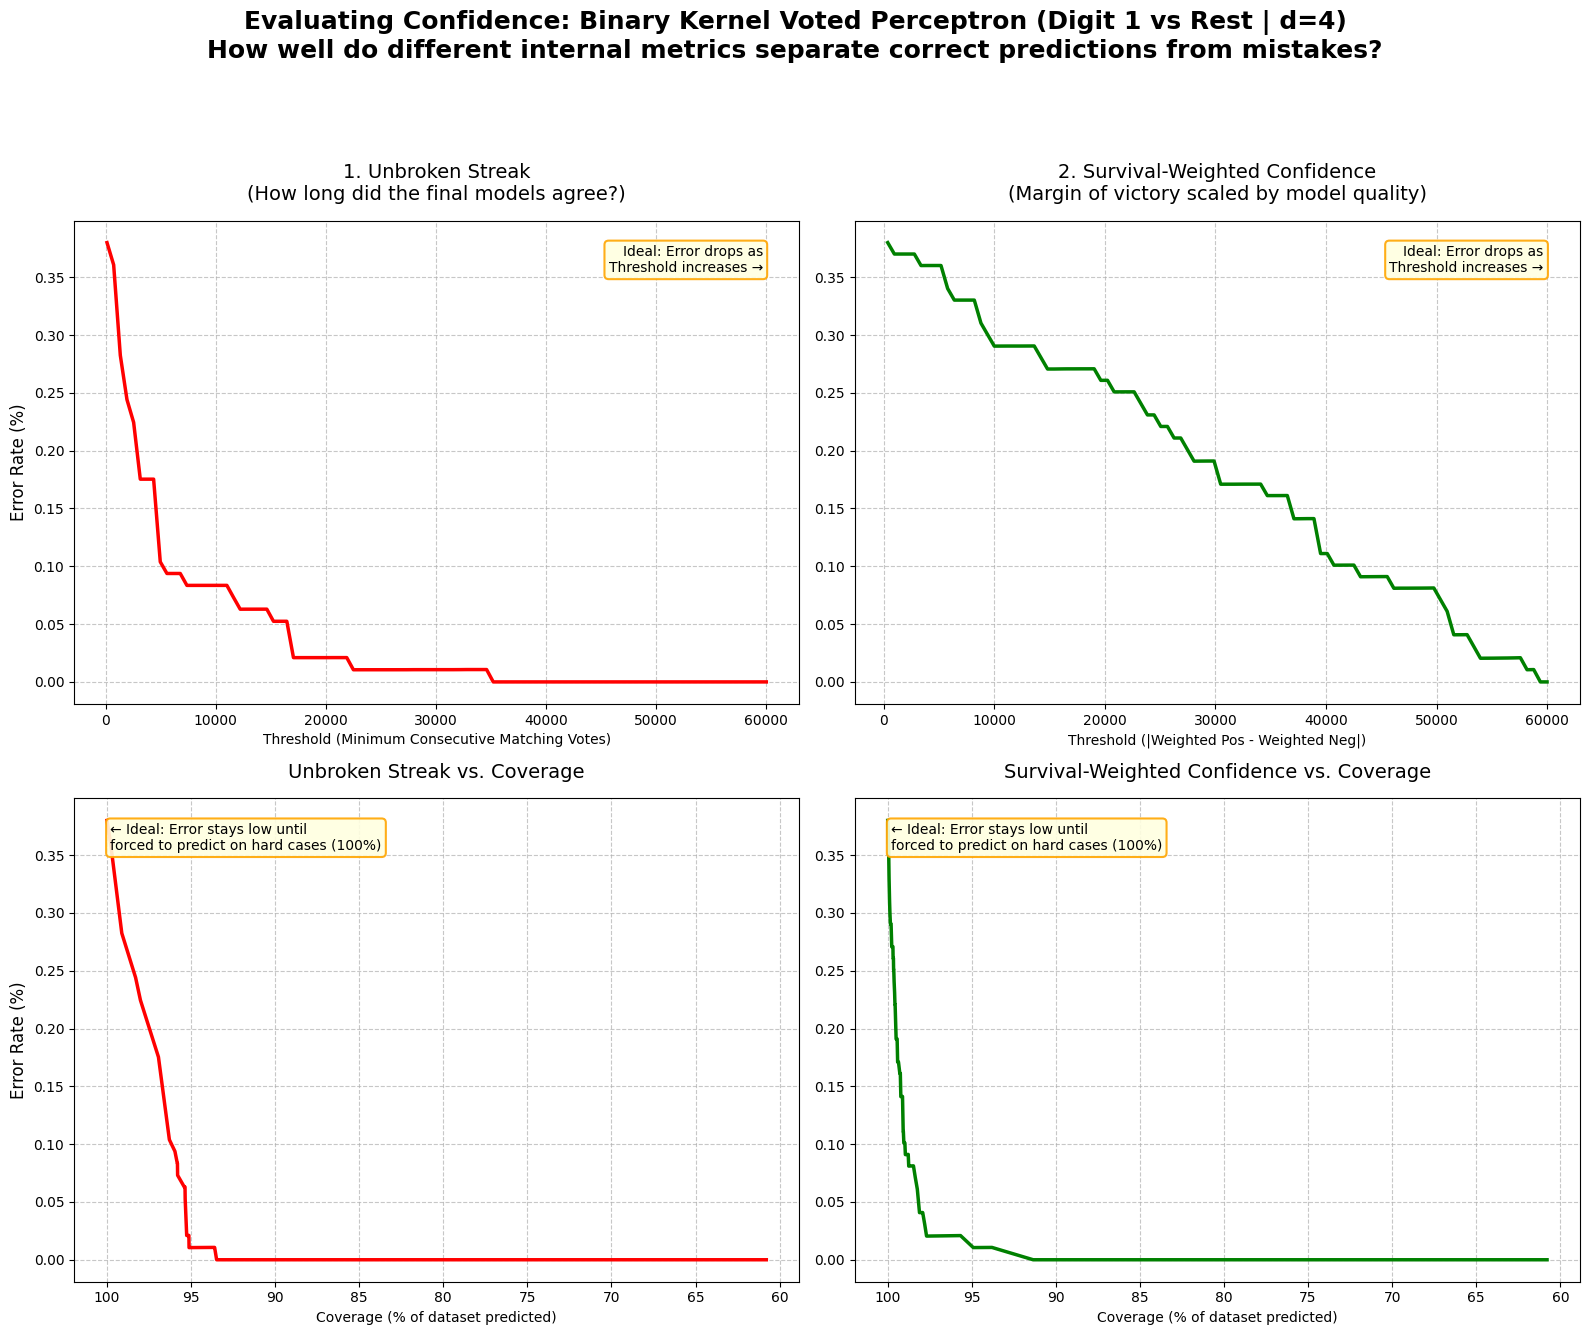


 STARTING EXPERIMENT FOR DIGIT: 2
--- Training: Digit 2 vs Rest | d=1, Epochs=1 ---
  > Training completed in 15.4s | Total mistakes: 2335
  > Evaluation Complete in 0.5s


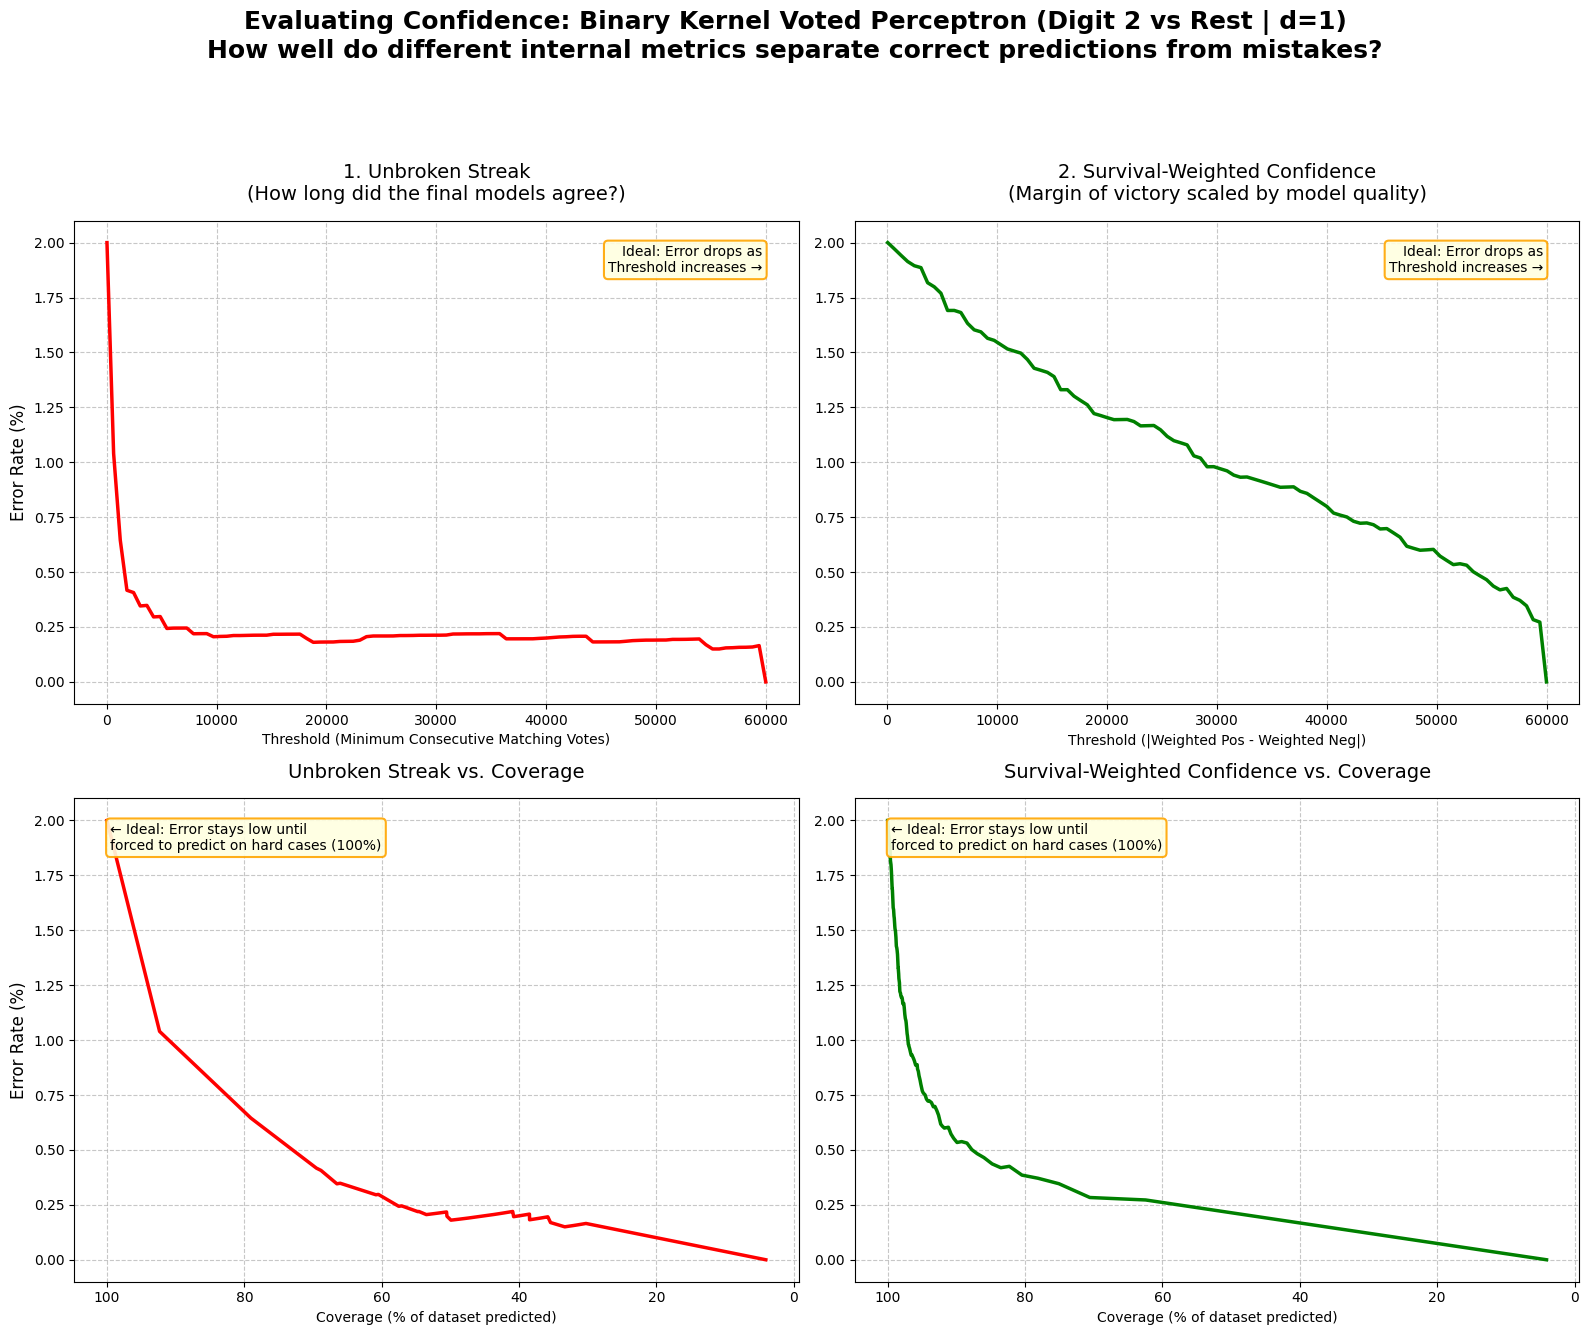

--- Training: Digit 2 vs Rest | d=2, Epochs=1 ---
  > Training completed in 12.1s | Total mistakes: 1021
  > Evaluation Complete in 0.2s


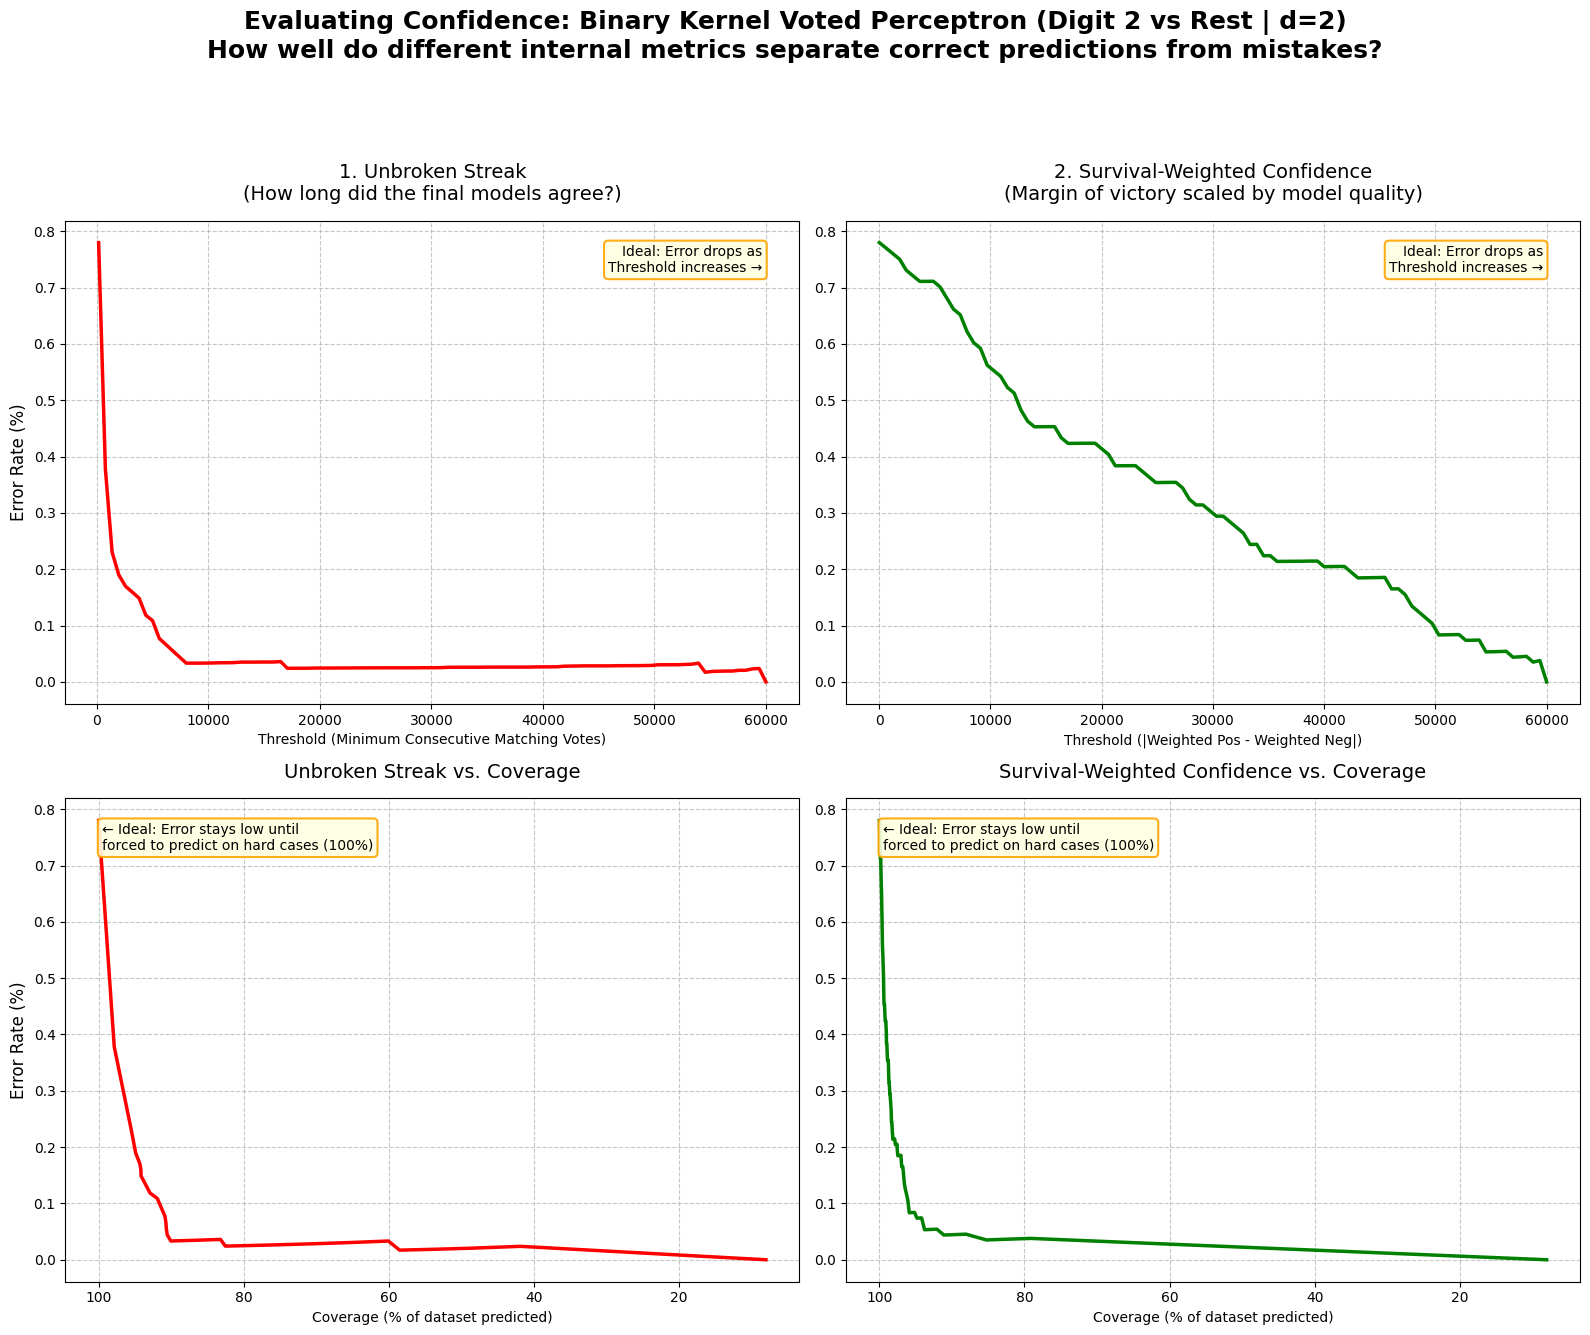

--- Training: Digit 2 vs Rest | d=3, Epochs=1 ---
  > Training completed in 11.7s | Total mistakes: 833
  > Evaluation Complete in 0.3s


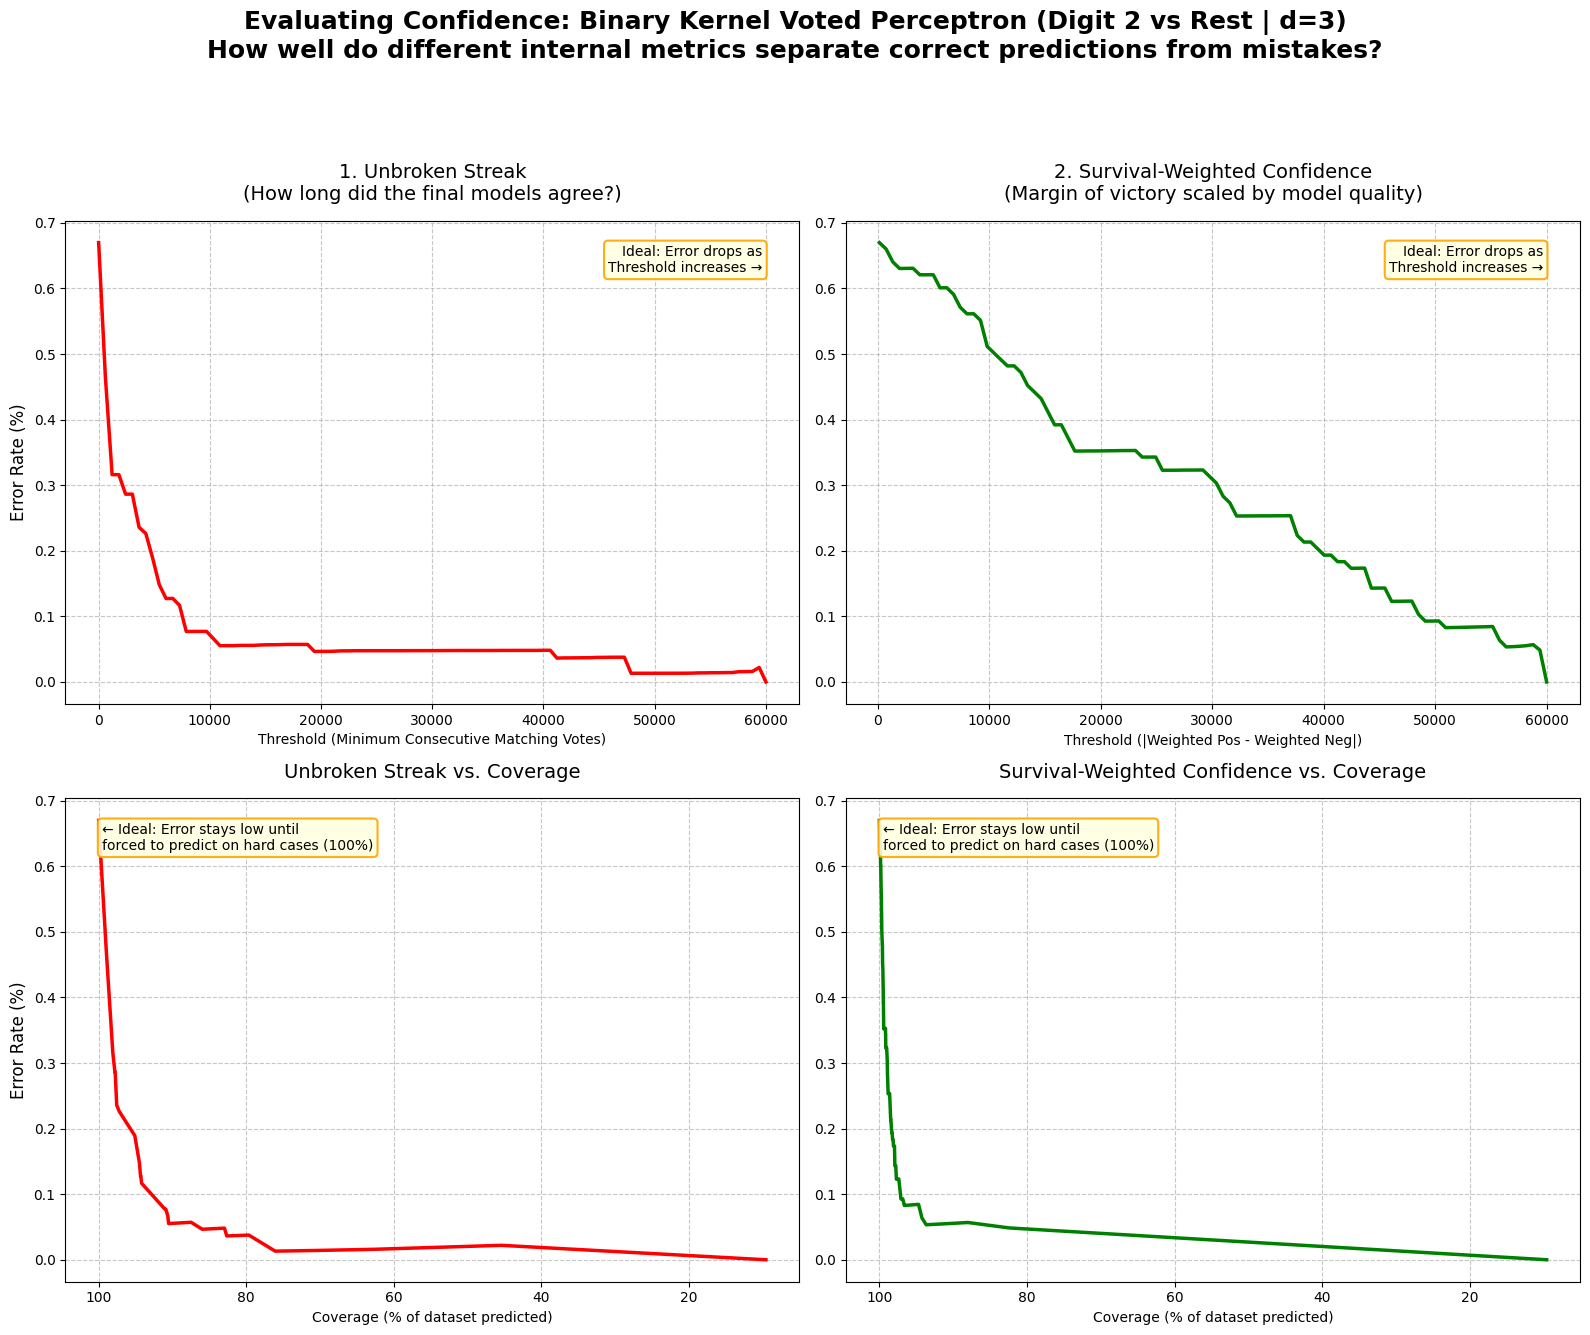

--- Training: Digit 2 vs Rest | d=4, Epochs=1 ---
  > Training completed in 12.7s | Total mistakes: 826
  > Evaluation Complete in 0.3s


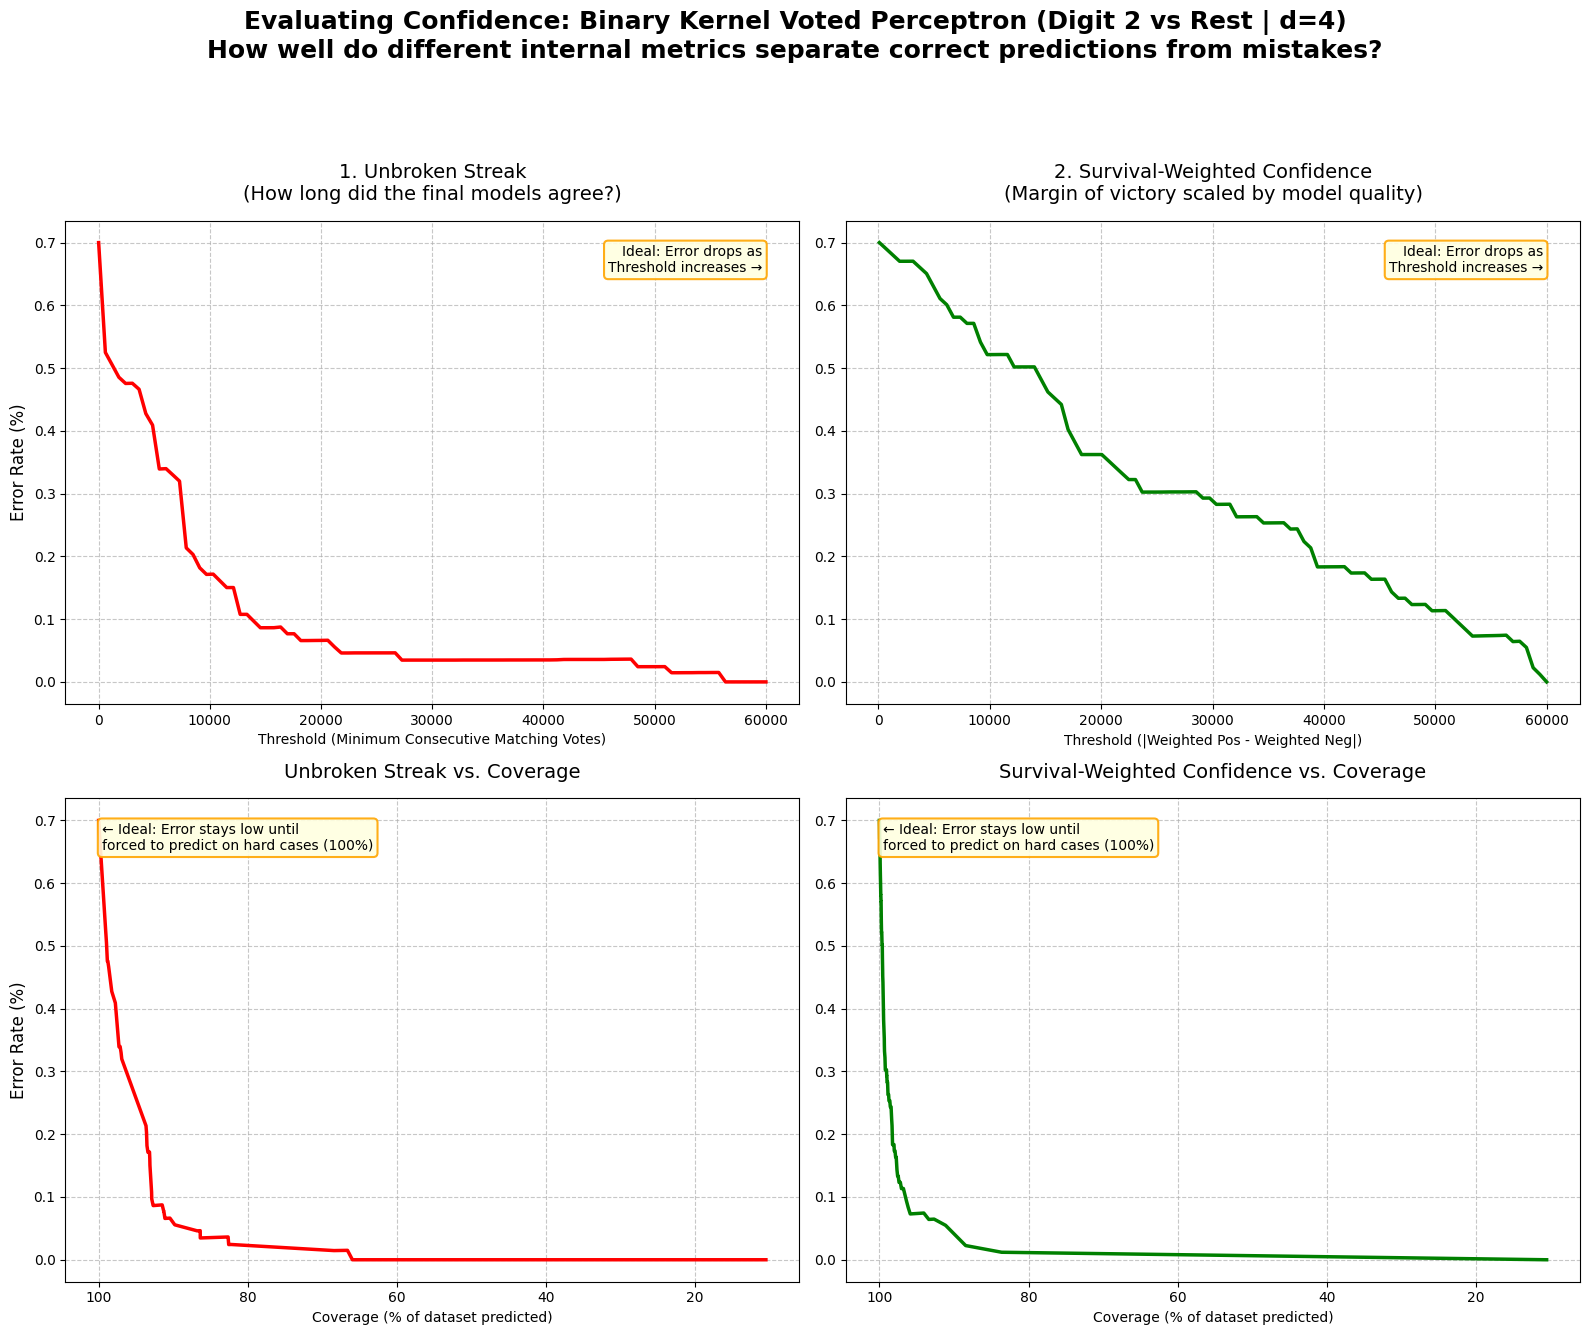


 STARTING EXPERIMENT FOR DIGIT: 3
--- Training: Digit 3 vs Rest | d=1, Epochs=1 ---
  > Training completed in 21.6s | Total mistakes: 2690
  > Evaluation Complete in 0.6s


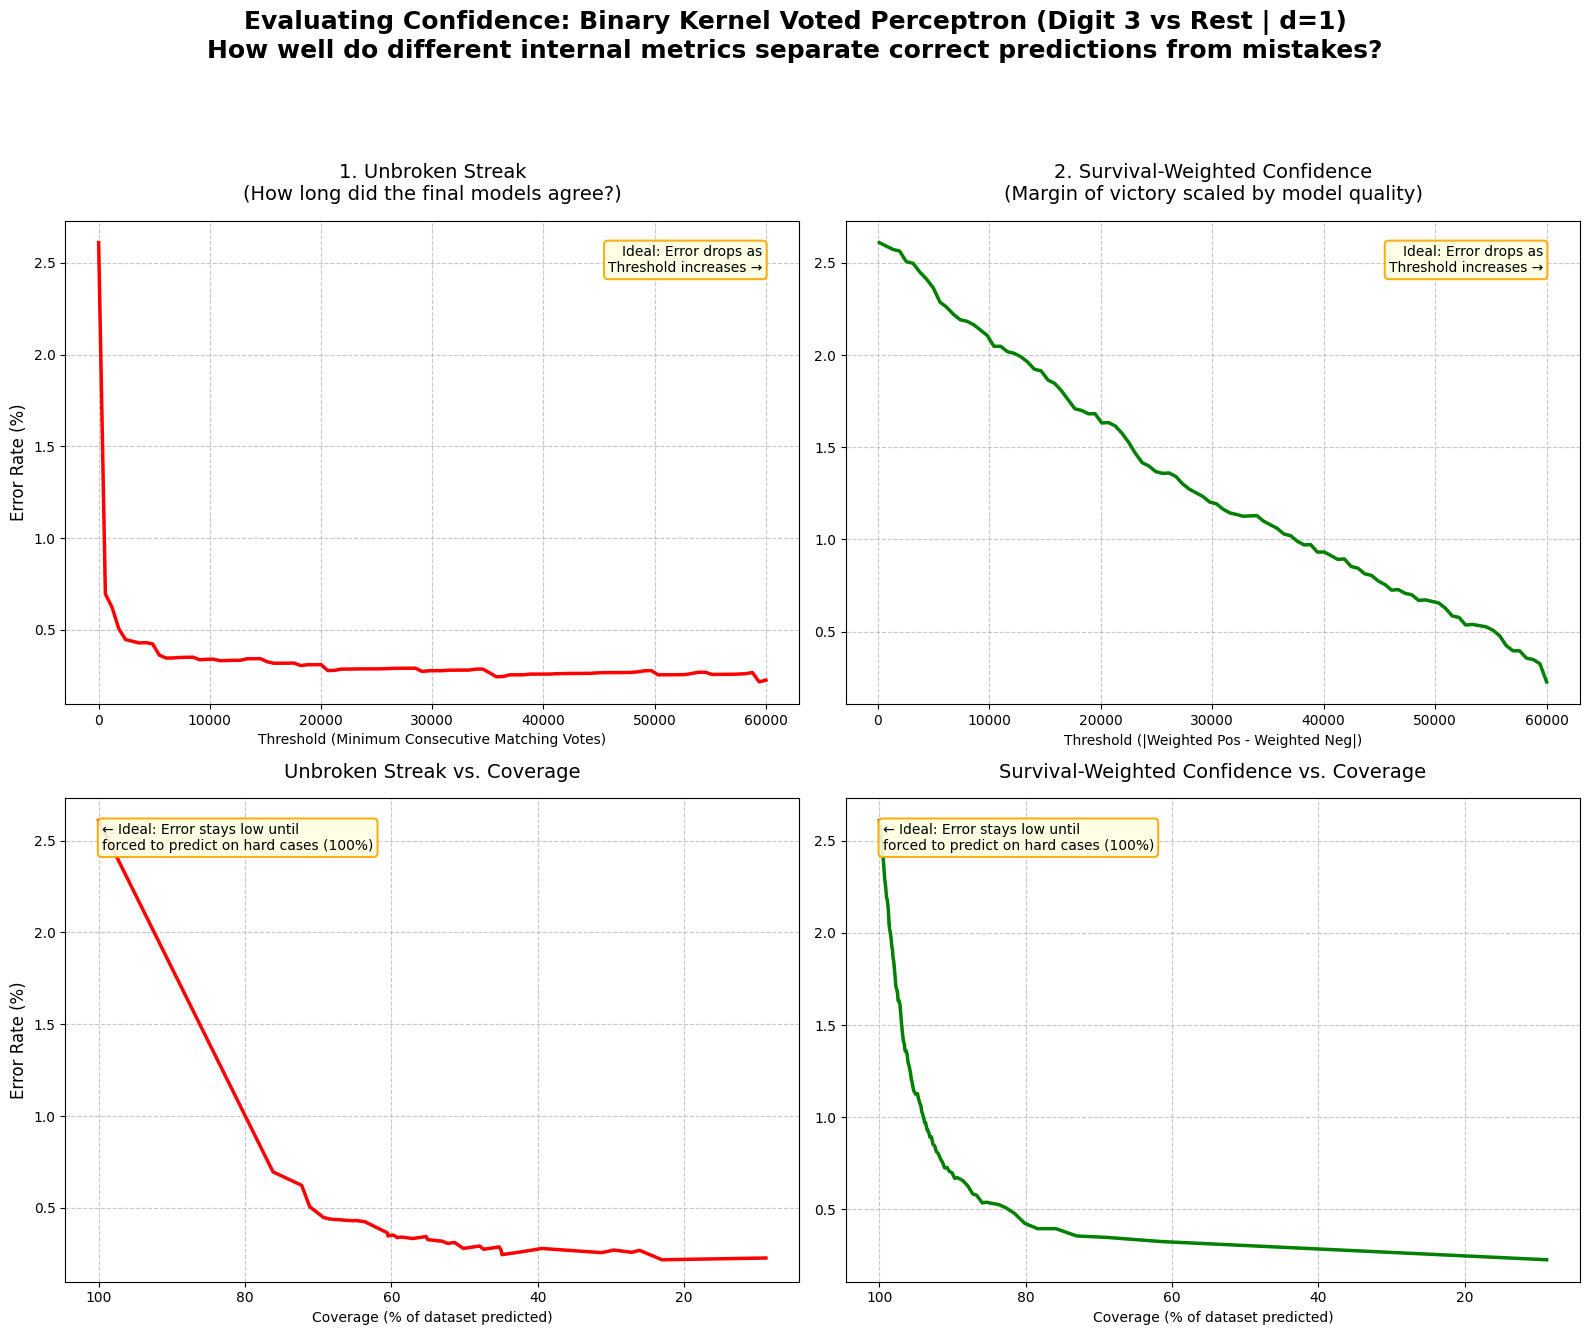

--- Training: Digit 3 vs Rest | d=2, Epochs=1 ---
  > Training completed in 15.1s | Total mistakes: 1265
  > Evaluation Complete in 0.3s


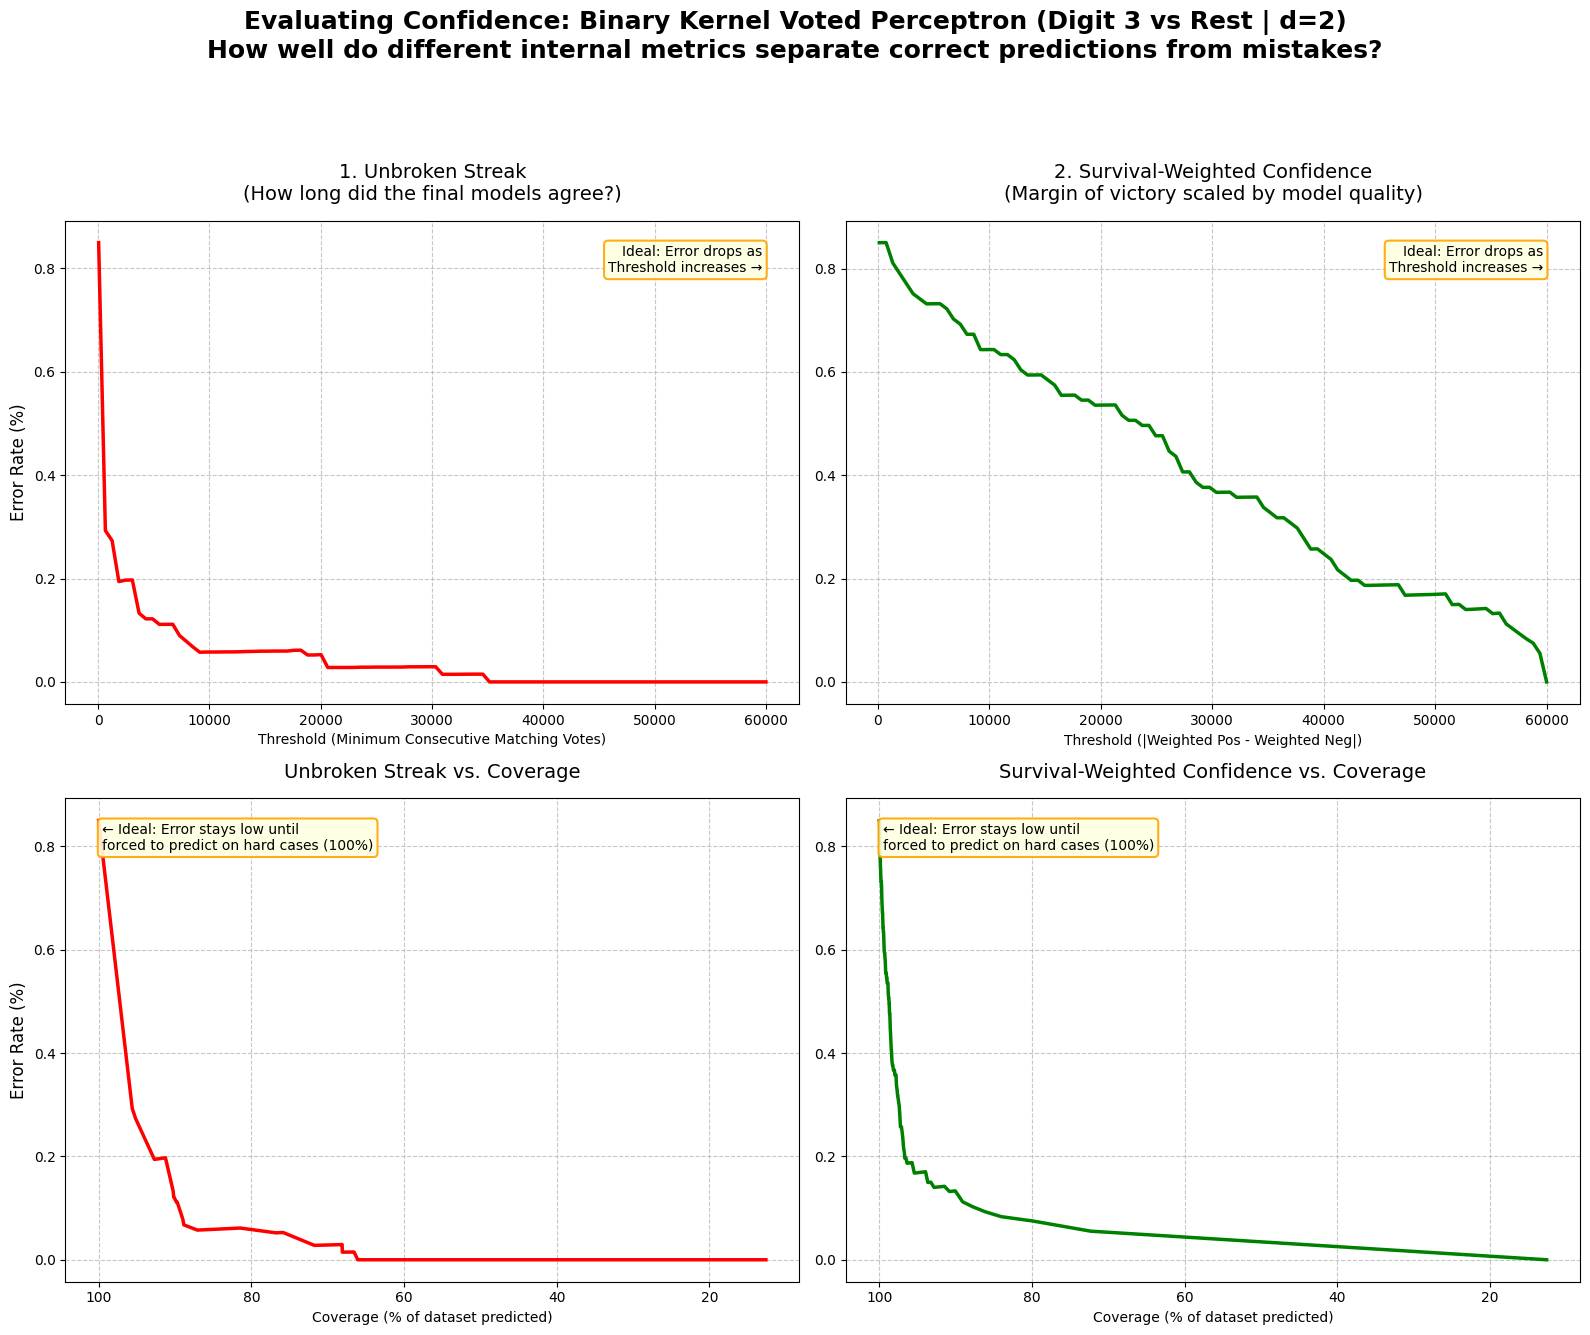

--- Training: Digit 3 vs Rest | d=3, Epochs=1 ---


In [ ]:
DEGREES = [1, 2, 3, 4]
EPOCHS = 1  # Kept to 1 for faster execution across 40 iterations
    
# Execute Pipeline
X_train, X_test, y_train_raw, y_test_raw = load_and_preprocess_data()
    
# Loop through all 10 digits
for digit in range(10):
    print(f"\n{'='*60}")
    print(f" STARTING EXPERIMENT FOR DIGIT: {digit}")
    print(f"{'='*60}")
        
    # Binarize targets for the specific digit
    y_train_bin = np.where(y_train_raw == digit, 1, -1)
    y_test_bin = np.where(y_test_raw == digit, 1, -1)
        
    # Loop through polynomial degrees
    for d in DEGREES:
        M_x, M_y, C_vec = train_voted_perceptron_binary(X_train, y_train_bin, target_digit=digit, d=d, epochs=EPOCHS)
        
        #Removed conf_abs_diff from the outputs here
        conf_streak, conf_margin, conf_weighted, mistakes = evaluate_binary(X_test, y_test_bin, M_x, M_y, C_vec, d=d)
        
        #Removed conf_abs_diff from the function call here
        plot_calibration(conf_streak, conf_weighted, mistakes, target_digit=digit, d=d)